In [64]:
from dotenv import load_dotenv
load_dotenv()

import os

import numpy as np
from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

import SZpack as SZ

from astropy.coordinates import SkyCoord
import astropy.units as u



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
HFI_FITS = fits.open("/home/gill/Downloads/HFI_RIMO_R3.00.fits")
LFI_FITS = fits.open("/home/gill/Downloads/LFI_RIMO_R3.31.fits")

In [6]:
# open binary table in the FITS file
# astorpy table import
from astropy.table import Table


In [39]:
HFI_TABLE = Table.read("/home/gill/Downloads/HFI_RIMO_R3.00.fits", hdu=1)

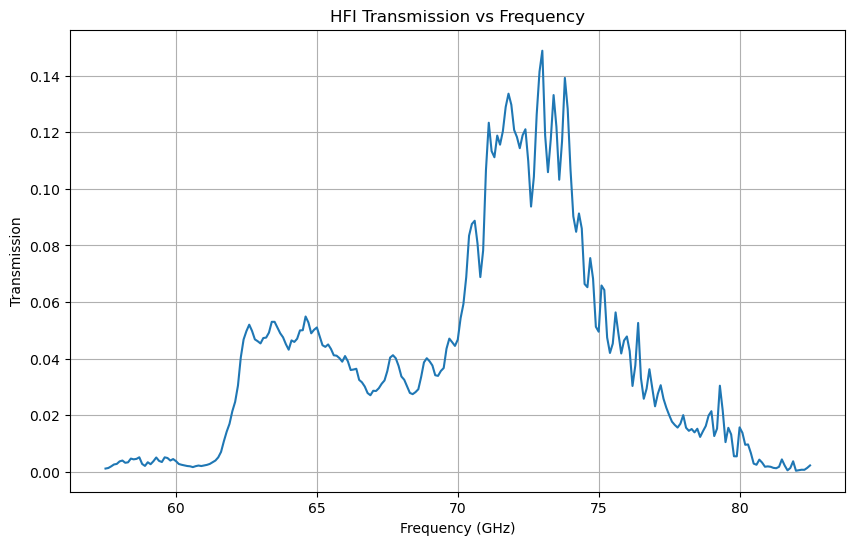

In [62]:
# Convert wavenumber to frequency in GHz
# wavenumber is in cm^-1, need to convert to Hz then GHz
# frequency = wavenumber * c (speed of light in cm/s)

wavenumber = LFI_FITS[14].data['WAVENUMBER']  # in cm^-1
transmission = LFI_FITS[14].data['TRANSMISSION']  # transmission values
c_cm_per_s = 2.998e10  # speed of light in cm/s
frequency_hz = wavenumber * c_cm_per_s
frequency_ghz = frequency_hz / 1e9  # convert Hz to GHz

plt.figure(figsize=(10, 6))
plt.plot(wavenumber, transmission)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Transmission')
plt.title('HFI Transmission vs Frequency')
plt.grid(True)
plt.show()

In [65]:
import utils as ut

In [ ]:
cf = ut.get_config_file("../configs/case10_ajay.yaml")


{'region_center_ra': 44.5916744,
 'region_center_dec': 13.2999979,
 'region_width': 2.1,
 'c1_ra': 44.742,
 'c1_dec': 13.594,
 'c1_ra_min': 44.735,
 'c1_ra_max': 44.745,
 'c1_dec_min': 13.57,
 'c1_dec_max': 13.59,
 'c1_muo': -0.5566122489553409,
 'c1_beta_min': 0.1,
 'c1_beta_max': 2,
 'c1_rc_arcmin_min': 0.1,
 'c1_rc_arcmin_max': 6,
 'c1_R_min': 0.2,
 'c1_R_max': 2,
 'c1_theta_min': 90,
 'c1_theta_max': 140.0,
 'c1_Te_mean': 8.47,
 'c1_Te_std': 0.25,
 'c1_mass': 10.2,
 'c1_z': 0.073664,
 'c1_Te_min': 1,
 'c1_Te_max': 15,
 'c1_Dtau_min': 0,
 'c1_Dtau_max': 0.02,
 'c1_A_D_min': 0,
 'c1_A_D_max': 2000000,
 'c2_ra': 44.473,
 'c2_dec': 13.03,
 'c2_ra_min': 44.452,
 'c2_ra_max': 44.48,
 'c2_dec_min': 13.025,
 'c2_dec_max': 13.065,
 'c2_muo': -0.5606024845891494,
 'c2_beta_min': 0.5,
 'c2_beta_max': 1.3,
 'c2_rc_arcmin_min': 0.1,
 'c2_rc_arcmin_max': 10,
 'c2_R_min': 0.2,
 'c2_R_max': 3,
 'c2_theta_min': 75,
 'c2_theta_max': 170,
 'c2_Te_mean': 7.23,
 'c2_Te_std': 0.19,
 'c2_mass': 8.7,
 'c2

In [131]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.size": 25,
    "axes.labelsize": 25,
    "axes.titlesize": 25,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})

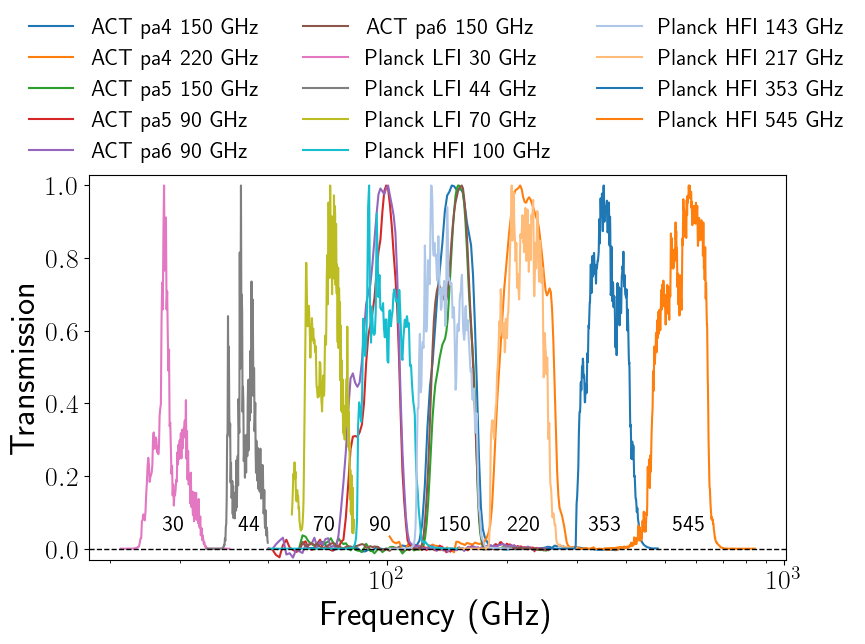

In [133]:
# latex rendering

plt.figure(figsize=(9, 5)) 

# Define a color palette with enough distinct colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8', '#ffbb78']

for i, data in enumerate(cf["data"]):
    freq = data.split('_')[0]
    array = data.split('_')[1]
    inst = data.split('_')[2]
    scan = data.split('_')[3]

    freq_str = ut.get_freq_str(frequency=freq)
    x_array, freq_array, del_freq = ut.get_freq_bandpass(array=array, freq_str=freq_str)
    bandpass, bandpass_int = ut.get_bandpass(array=array, freq_str=freq_str)

    # normalize bandpass
    bandpass /= np.max(bandpass)

    if freq == "98":
        freq = "90"
    
    if "pa" in array: 
        label = f"ACT {array} {freq} GHz"
        linestyle = '-'
    elif int(freq) < 100:
        label = f"Planck LFI {freq} GHz"
        linestyle = 'solid'
    else:
        label = f"Planck HFI {freq} GHz"
        linestyle = 'solid'

    # Use modulo to cycle through colors without repetition until we run out
    color = colors[i % len(colors)]
    plt.semilogx(freq_array, bandpass, label=label, color=color, linestyle=linestyle)

plt.xlabel('Frequency (GHz)')
plt.ylabel('Transmission')
plt.axhline(0, color='black', lw=1, ls='--')
plt.legend(bbox_to_anchor=(0.5, 0.98), loc='lower center', ncol=3, frameon=False, fontsize=16)

plt.text(27, 0.05, "30", fontsize=16, color='black')
plt.text(42, 0.05, "44", fontsize=16, color='black')
plt.text(65, 0.05, "70", fontsize=16, color='black')
plt.text(90, 0.05, "90", fontsize=16, color='black')
plt.text(135, 0.05, "150", fontsize=16, color='black')
plt.text(200, 0.05, "220", fontsize=16, color='black')
plt.text(320, 0.05, "353", fontsize=16, color='black')
plt.text(520, 0.05, "545", fontsize=16, color='black')
plt.ylim(-0.03, 1.03)
plt.savefig("../plots/bandpasses.pdf", bbox_inches='tight', dpi=500)
plt.show()
